In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import trange, tqdm
from matplotlib import gridspec
import pandas as pd
import pickle
np.random.seed(10)
random.seed(10)

# parameters
G0 = 77.84      # Reference conductance (G0)
num_points = 1000  # Number of samples per trace (trace length)
d_limit_down = 0   
d_limit_up = 4     
d = np.linspace(d_limit_down, d_limit_up, num_points)  # Uniformly sampled d-axis
beta = 10

lm_1 = 1.0 # Tunneling region: end position of tunneling / start of the plateau
lm_2 = 2.5 # Background region: start position of the background

tail_prob = 0.35          # Fraction of traces that exhibit a tail
tail_scale = 0.25          # Tail strength (larger -> longer tail)

In [2]:
def vis_data(d, logG):
    ''' visualize log G data'''
    
    fig = plt.figure(figsize=(12, 14))
    gs = gridspec.GridSpec(4, 4)
    
    ax1 = plt.subplot(gs[0:2, 0:2])
    plt.plot(d, logG[0, :], linewidth=2)
    
    ax2 = plt.subplot(gs[0:2, 2:4])
    plt.hist(logG[0, :], bins=500, color='g', alpha=0.8, label='Single Curve')
    plt.legend(fontsize='x-large')
    
    ax3 = plt.subplot(gs[2:, 0:2])
#     x_line = -5.6
#     plt.axvline(x_line, color='red', linestyle='--', linewidth=1.8, label=f'x = {x_line:.2f}')
    plt.hist(logG.reshape(-1), bins=500, color='g', alpha=0.8, label='All Curve')
    plt.legend(fontsize='x-large')
    
    ax4 = plt.subplot(gs[2:, 2:4])
    m = logG.shape[0]
    dist = np.repeat(d.reshape([1, -1]), m, axis=0)
    plt.hist2d(dist.reshape([-1, ]), logG.reshape([-1, ]), bins=200)

In [3]:
# Convert to log10(G) only when input is not already in log scale
def to_log10_g(trace, is_log=True):
    trace = np.asarray(trace, dtype=np.float64)
    if is_log:
        return trace
    return np.log10(trace)

def get_trace_modes_from_matrix(raw_traces, range_min, range_max, bin_width, is_log=True):
    extracted_modes = []
    bins = np.arange(range_min, range_max + bin_width, bin_width)

    for trace in raw_traces:
        log_t = to_log10_g(trace, is_log)

        # Keep finite values within [range_min, range_max]
        valid_mask = np.isfinite(log_t) & (log_t >= range_min) & (log_t <= range_max)
        gated = log_t[valid_mask]

        if len(gated) >= 5:
            counts, edges = np.histogram(gated, bins=bins)
            if counts.sum() > 0:
                # Mode = center of the highest-count bin (average if multiple bins tie)
                max_count = counts.max()
                max_bins_indices = np.flatnonzero(counts == max_count)
                centers = (edges[max_bins_indices] + edges[max_bins_indices + 1]) / 2
                mode_val = centers.mean()
                extracted_modes.append(mode_val)

    return np.array(extracted_modes, dtype=np.float64)

In [4]:
def logG_tunneling(x, beta, G0=77.84):
    """Linear-scale tunneling: G = G0 * exp(-beta * x)"""
    return G0 * np.exp(-beta * x)

def logG_gaussian_platform(x, yskew=0.0, noise_miu=0.0, noise_sigma=0.3):
    """
    Plateau/background in logG:
    logG = yskew + noise_miu + N(0, noise_sigma)
    x can be a scalar or array; output matches x shape.
    """
    x = np.asarray(x)
    return yskew + noise_miu + np.random.randn(*x.shape) * noise_sigma

def generator(
    x, tunneling_function, platform_function, num_curves=2000,
    # Segment params
    lm_1=1.0, lm2_mu=3.2, lm2_sigma=0.08, beta=10.0, G0=77.84,
    # Plateau/background stats
    step_level=-5.0, bg_level=-8.0,
    step_noise_sigma=0.45, step_level_jitter=0.20,
    bg_noise_sigma=0.18, bg_level_jitter=0.06,
    tunnel_noise_sigma=0.02,
    # Tail (applied to step_c)
    tail_prob=0.35, tail_scale=0.25,
):
    """
    Generate num_curves logG traces (shape: [num_curves, len(x)]).
    Piecewise: tunneling -> plateau (step) -> background.
    """
    x = np.asarray(x, dtype=np.float32)
    n = x.size
    logG = np.empty((num_curves, n), dtype=np.float32)

    # Tunneling baseline in log10(G/G0)
    tunnel_base = np.log10(tunneling_function(x, beta, G0=G0) / G0).astype(np.float32)

    for c in trange(num_curves):
        # lm_2: end of plateau for this trace
        lm_2 = float(np.clip(np.random.normal(lm2_mu, lm2_sigma), lm_1 + 0.1, float(x[-1])))

        # Background center (per-trace)
        bg_c = float(np.random.normal(bg_level, bg_level_jitter))

        # Plateau center (per-trace) + optional left tail
        step_c = float(np.random.normal(step_level, step_level_jitter))
        if np.random.rand() < tail_prob:
            step_c -= float(np.random.exponential(scale=tail_scale))  # left tail only

        # Segment masks (no blend)
        m_tun  = x < lm_1
        m_step = (x >= lm_1) & (x < lm_2)
        m_bg   = x >= lm_2

        y = np.empty(n, dtype=np.float32)

        # Tunneling segment
        if m_tun.any():
            idx = np.where(m_tun)[0]
            y[idx] = tunnel_base[idx] + np.random.randn(idx.size).astype(np.float32) * tunnel_noise_sigma

        # Plateau (step) segment
        if m_step.any():
            xs = x[m_step]
            y[m_step] = platform_function(xs, yskew=step_c, noise_sigma=step_noise_sigma).astype(np.float32)

        # Background segment
        if m_bg.any():
            xg = x[m_bg]
            y[m_bg] = platform_function(xg, yskew=bg_c, noise_sigma=bg_noise_sigma).astype(np.float32)

        logG[c] = y

    return logG

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 11370.34it/s]


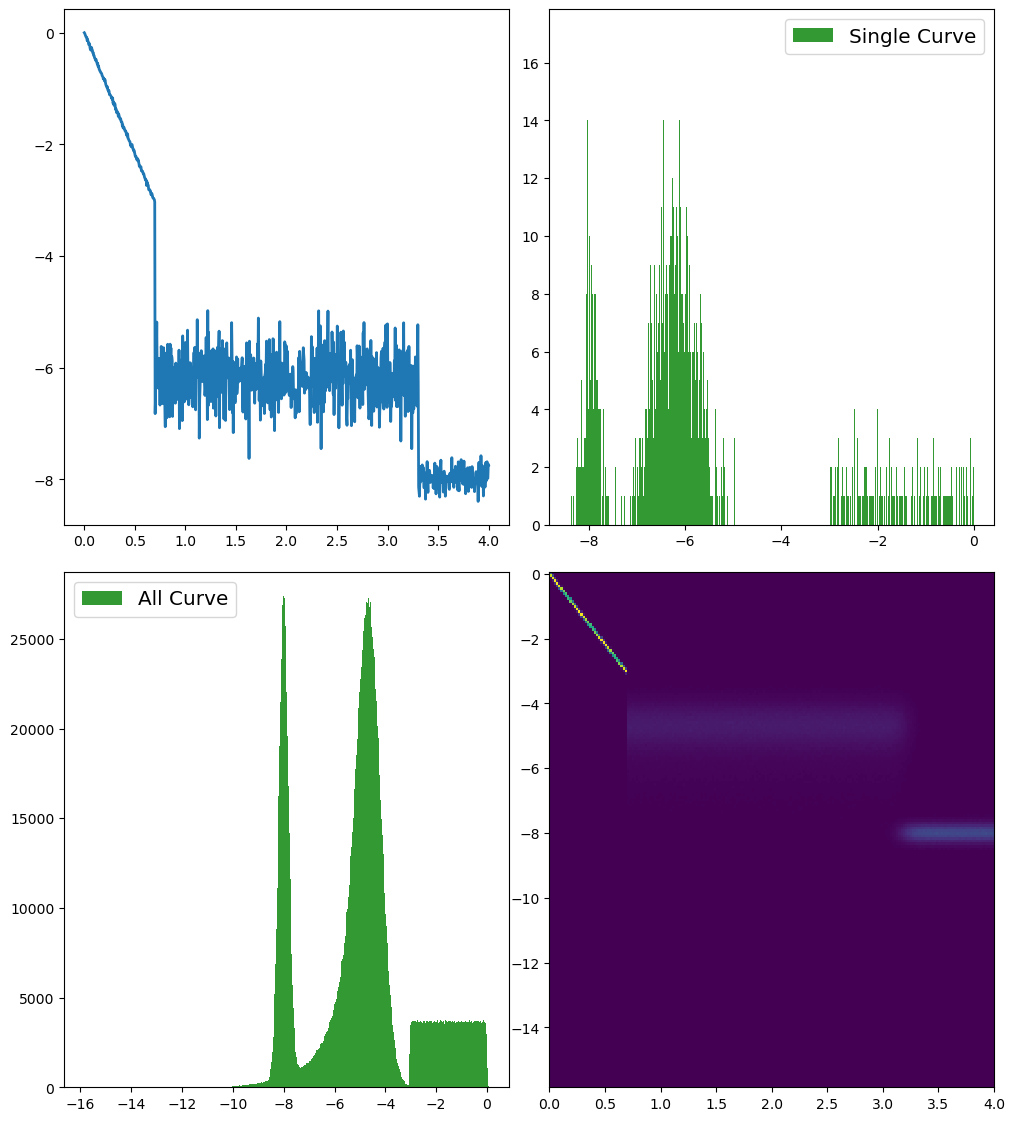

In [5]:
logG_gauss = generator(
    d, logG_tunneling, logG_gaussian_platform, num_curves=2000, lm_1=0.7,                
    step_level=-4.6, bg_level=-8.0,
    step_noise_sigma=0.45, step_level_jitter=0.1,
    bg_noise_sigma=0.18, bg_level_jitter=0.06,
    lm2_mu=3.2, lm2_sigma=0.08,
    tail_prob=0.4, tail_scale=1,
)
vis_data(d, logG_gauss)


In [6]:
# Save the generated data matrix
np.save("logG_gauss-simulated.npy", logG_gauss.astype(np.float64))

# Load back for sanity check
x = np.load("logG_gauss-simulated.npy")
print(x.shape, x.dtype)

(2000, 1000) float64


In [7]:
modes_step = get_trace_modes_from_matrix(
    raw_traces=logG_gauss,
    range_min=-6,
    range_max=-4,
    bin_width=0.02,
    is_log=True
)
print("Extracted modes:", modes_step.shape, "mean=", modes_step.mean(), "std=", modes_step.std())

Extracted modes: (1940,) mean= -4.85062663230243 std= 0.45241741090428556


In [8]:
import pymc as pm
from scipy import stats


def bayes_student_t_posterior_pdf_1group(
    data, x_grid, random_seed, draws=2000, tune=1000, chains=2,
):
    """
    Fit a 1-group Student-t model with Bayesian inference, then return the
    posterior predictive PDF on a given x_grid (via Monte Carlo averaging).
    """
    y = np.asarray(data, dtype=np.float64)
    y = y[np.isfinite(y)]
    if y.size < 5:
        return None

    # pooled stats for weakly-informative priors 
    pooled_mean = float(np.mean(y)) if y.size > 1 else 0.0
    pooled_std = float(np.std(y)) if y.size > 1 else 1.0
    pooled_std = max(pooled_std, 1e-4)  # avoid degenerate prior scales

    # build and sample model
    with pm.Model() as model:
        # Priors 
        mu = pm.Normal("mu", mu=pooled_mean, sigma=pooled_std * 5)
        sigma = pm.HalfNormal("sigma", sigma=pooled_std * 5)
        nu = pm.Exponential("nu_minus_one", 1 / 29.0) + 1.0  

        # Likelihood
        pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=y)

        try:
            trace = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                random_seed=random_seed,   # controls reproducibility
                progressbar=False,
                init="adapt_diag",
                target_accept=0.95,
                cores=1,
            )
        except Exception as e:
            print(f"Bayesian sampling failed internal: {e}")
            return None

    # flatten posterior samples
    mu_s = trace.posterior["mu"].values.reshape(-1)
    sigma_s = trace.posterior["sigma"].values.reshape(-1)
    nu_s = trace.posterior["nu_minus_one"].values.reshape(-1) + 1.0

    # posterior predictive density on grid (mixture of Student-t)
    # pdf(x) ≈ (1/S) * Σ_s t_pdf(x | nu_s, mu_s, sigma_s)
    pdf_bayes = np.mean(
        stats.t.pdf(
            x_grid[None, :],
            nu_s[:, None],
            loc=mu_s[:, None],
            scale=sigma_s[:, None],
        ),
        axis=0,
    )

    return {
        "pdf": pdf_bayes,
        "nu_samples": nu_s,
        "mu_samples": mu_s,
        "sigma_samples": sigma_s,
        "pooled_mean": pooled_mean,
        "pooled_std": pooled_std,
    }

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, sigma, nu_minus_one]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 13 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


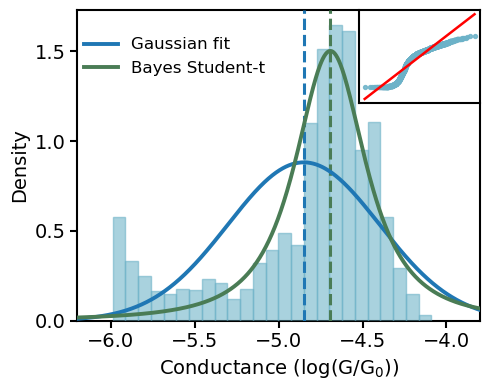

In [15]:
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.ticker import MaxNLocator

# settings: fit/plot ranges
fit_range  = (-6, -4)       # Use only data in this interval for fitting
plot_range = (-6.2, -3.8)   # Visible x-range in the plot
bins = 25

# Style
LABEL_FS = 14
TICK_FS  = 14
SPINE_LW = 1.5
TICK_W   = 1.5
TICK_L   = 5

# Colors (blue theme)
HIST_BLUE  = "#6cb2c8"
DEEP_BLUE  = "#4a7c55"   # Bayesian Student-t
GAUSS_BLUE = "#1f77b4"

# Data cleanup
y_all = np.asarray(modes_step, dtype=np.float64)
y_all = y_all[np.isfinite(y_all)]
assert y_all.size >= 5

# Fit subset
a, b = fit_range
y_fit = y_all[(y_all >= a) & (y_all <= b)]
assert y_fit.size >= 5, f"Too few samples in fit_range: {y_fit.size}"

# Grid for plotting PDFs
c, d = plot_range
x_grid = np.linspace(c, d, 800)

# Gaussian fit
mu_hat, sigma_hat = stats.norm.fit(y_fit)
pdf_gauss = stats.norm.pdf(x_grid, loc=mu_hat, scale=sigma_hat)

# Bayesian Student-t
bayes_res = bayes_student_t_posterior_pdf_1group(
    data=y_fit,
    x_grid=x_grid,
    random_seed=42,
    draws=2000,
    tune=1000,
    chains=2,
)

# Plot: histogram + fitted curves
fig, ax = plt.subplots(figsize=(5, 4))

# Histograms (density)
ax.hist(
    y_all, bins=bins, density=True,
    color=HIST_BLUE, edgecolor=HIST_BLUE,
    alpha=0.35, linewidth=1.0, zorder=2,
)
ax.hist(
    y_fit, bins=bins, density=True,
    color=HIST_BLUE, edgecolor=HIST_BLUE,
    alpha=0.35, linewidth=1.0, zorder=3,
)

# Gaussian PDF + mean line
line_gauss, = ax.plot(x_grid, pdf_gauss, linewidth=2.8, color=GAUSS_BLUE, zorder=20, label="Gaussian fit")
ax.axvline(mu_hat, linewidth=2.2, linestyle="--", color=GAUSS_BLUE, zorder=19)

# Bayesian Student-t PDF + posterior mean line
line_t = None
if bayes_res is not None:
    line_t, = ax.plot(x_grid, bayes_res["pdf"], linewidth=2.8, color=DEEP_BLUE, zorder=21, label="Bayes Student-t")
    mu_bayes = float(np.mean(bayes_res["mu_samples"]))
    ax.axvline(mu_bayes, linewidth=2.2, linestyle="--", color=DEEP_BLUE, zorder=19)

# Axes styling (keep ticks, hide tick labels)
# ax.set_xlim(c, d)
# ax.tick_params(axis="x", labelsize=TICK_FS, width=TICK_W, length=TICK_L, labelbottom=False)
# ax.tick_params(axis="y", labelsize=TICK_FS, width=TICK_W, length=TICK_L, labelleft=False)
# ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

# for s in ax.spines.values():
#     s.set_linewidth(SPINE_LW)

ax.set_xlim(c, d)
ax.set_xlabel(r"Conductance (log(G/G$_0$))", fontsize=LABEL_FS)
ax.set_ylabel("Density", fontsize=LABEL_FS)

ax.tick_params(axis="y", labelsize=TICK_FS, width=TICK_W, length=TICK_L)
ax.tick_params(axis="x", labelsize=TICK_FS, width=TICK_W, length=TICK_L)
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

for s in ax.spines.values():
    s.set_linewidth(SPINE_LW)

# Legend
handles = [line_gauss] + ([line_t] if line_t is not None else [])
labels  = ["Gaussian fit"] + (["Bayes Student-t"] if line_t is not None else [])

ax.legend(
    handles, labels,
    frameon=False, fontsize=12,
    loc="center left",
    bbox_to_anchor=(-0.02, 0.85)   
)

# Inset: Gaussian QQ plot 
w, h = 0.30, 0.30
x0, y0 = 1 - h, 1 - h  
axins = ax.inset_axes([x0, y0, w, h])

z = (y_fit - mu_hat) / (sigma_hat + 1e-12)  
z = np.sort(z)
p = (np.arange(1, z.size + 1) - 0.5) / z.size
q = stats.norm.ppf(p)

axins.scatter(q, z, s=8, alpha=0.85, color=HIST_BLUE)
lo = float(min(q.min(), z.min()))
hi = float(max(q.max(), z.max()))
axins.plot([lo, hi], [lo, hi], linewidth=1.8, color="red")

# inset styling
axins.set_xticks([])
axins.set_yticks([])
axins.patch.set_visible(False)
axins.spines["right"].set_visible(False)
axins.spines["top"].set_visible(False)
axins.spines["bottom"].set_linewidth(1.5)
axins.spines["left"].set_linewidth(1.5)

plt.tight_layout()
plt.show()